# Задание 5

### Бганцова Полина Б06-305

Структура папок на сервере:

In [ ]:
hw5_single/
├── data/                 # скачанные .fastq.gz файлы
├── scripts/              # SLURM‑скрипты
├── results/              # результаты FastQC и MultiQC
├── logs/                 # логи SLURM
└── trimmed_data/         # данные после тримминга

## **Часть 1 - Анализ FastQC**



Из проекта PRJEB84057 (древняя ДНК человека) были скачаны 4 single‑end файла в формате FASTQ с помощью SRA Explorer. Размер каждого файла не превышает 1000 Мб.

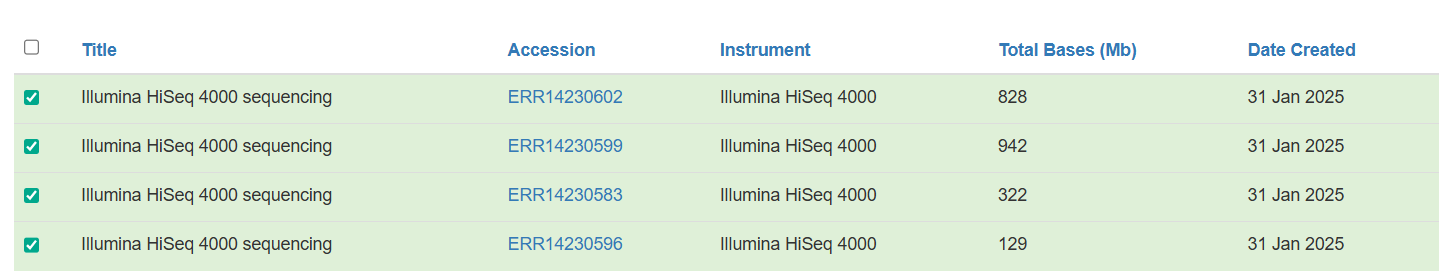

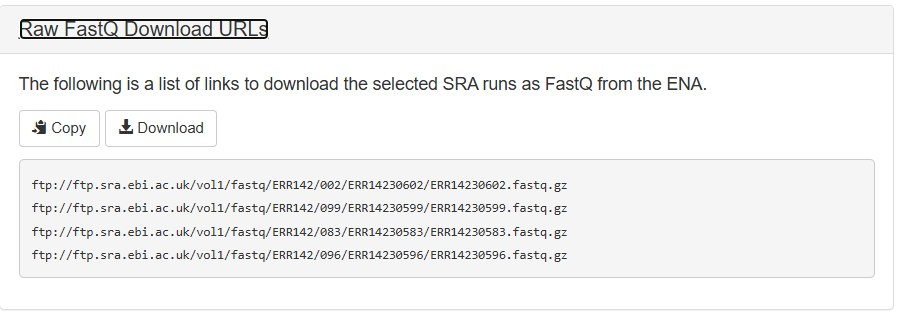

Скрипт для скачивания файлов `download.slurm`




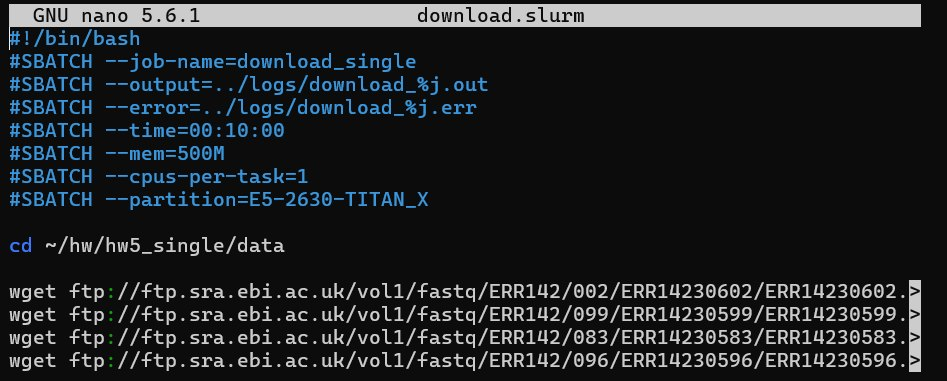

После выполнения файла `download.slurm` проверим, что данные скачаны

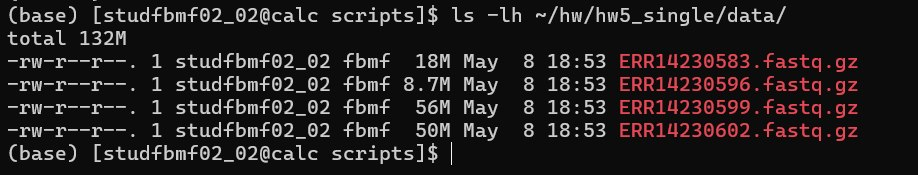

Скрипт для **FastQC** `fastqc_raw.slurm`

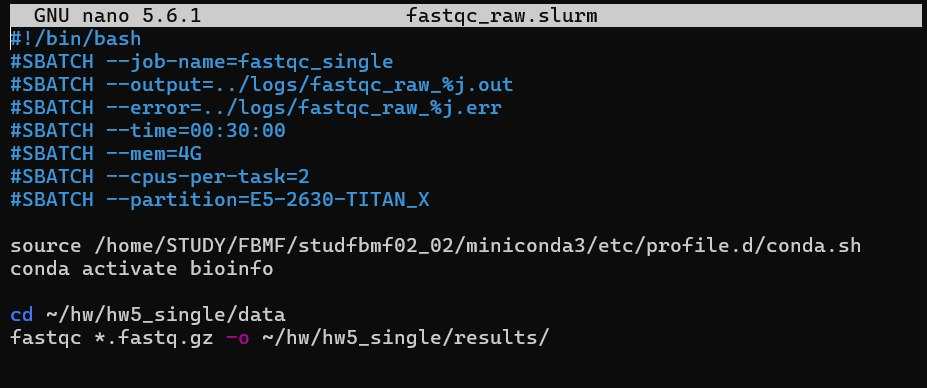

Скрипт для MultiQC – `scripts/multiqc_raw.slurm`

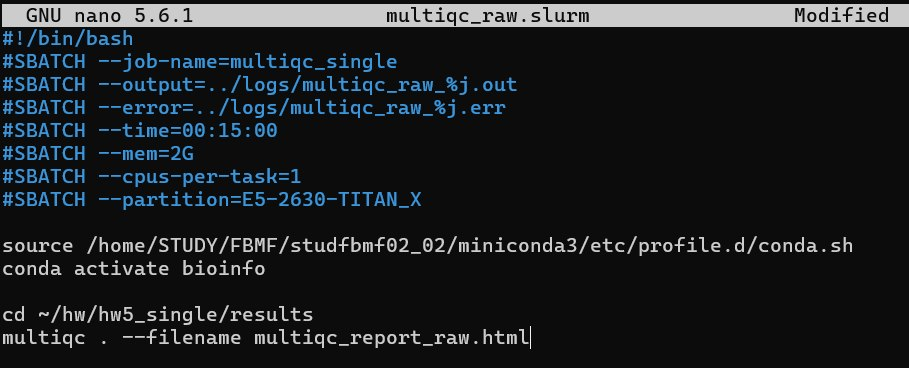

После выполнения скриптов

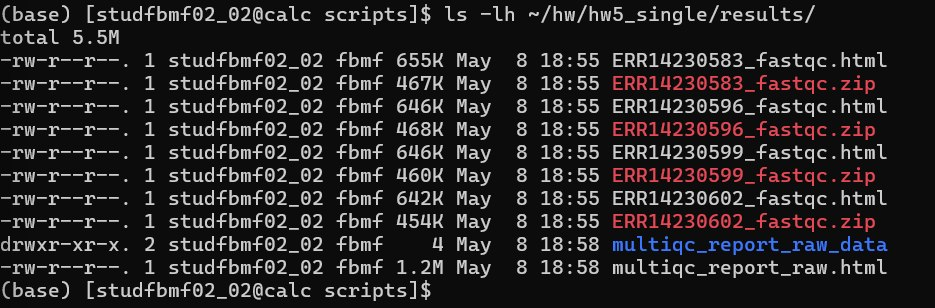

Откроем отчёт MultiQC и посмотрим на данные

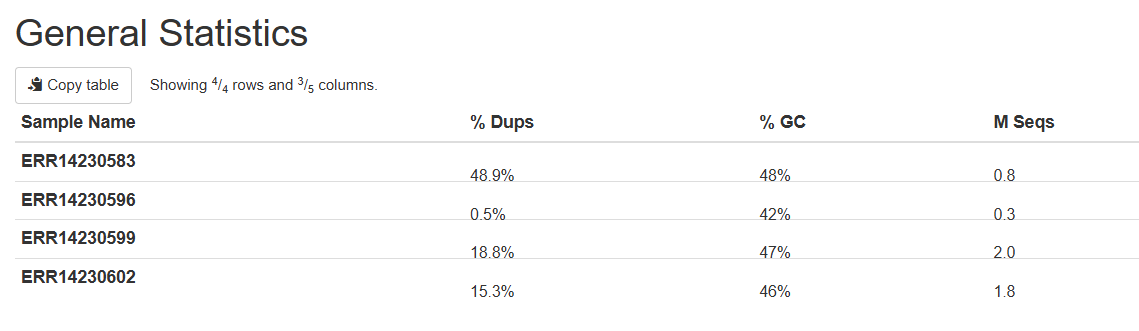

**Анализ результатов**

- **ERR14230583:** Очень высокая дупликация (48,9%) при малом объёме (0,8M). GC (48%) нормальный. Причина высокой дупликации – вероятно, избыточная ПЦР-амплификация или наличие адаптерных димеров. Малое число ридов снижает статистическую надёжность.

- **ERR14230596:** Крайне низкое покрытие (0,3M) – данных недостаточно для большинства видов анализа. Дупликация (0,5%) очень низкая, GC (42%) ниже среднего. Причина малого объёма – возможно, потеря материала на этапе подготовки библиотеки или недоосеквенирование.

- **ERR14230599:** Умеренная дупликация (18,8%) и хорошее покрытие (2,0M). GC (47%) в норме. Дупликация не критична, объём достаточен для анализа.

- **ERR14230602:** Дупликация (15,3%) умеренная, покрытие (1,8M) хорошее, GC (46%) в норме. Этот образец наиболее пригоден для дальнейшей обработки.

---
**Итого**
- У двух образцов (ERR14230583 и ERR14230596) слишком мало ридов для надёжного анализа.  
- Высокая дупликация у ERR14230583 (48,9%) указывает на возможную контаминацию или проблемы на этапе амплификации.  
- GC-состав варьируется от 42% до 48% – в пределах допустимого для бактериальных или метагеномных данных.  


## **Часть 2  — Тримминг**

- **Есть ли в ваших данных адаптеры?**

Да, адаптеры присутствуют, но в очень малом количестве. У трёх образцов уровень контаминации ниже 0,1% (порог отображения MultiQC), у одного образца (ERR14230596) – около 0,15% на 65-й позиции.

Такие значения обычно не требуют обязательной обрезки, однако для строгости анализа их можно удалить.

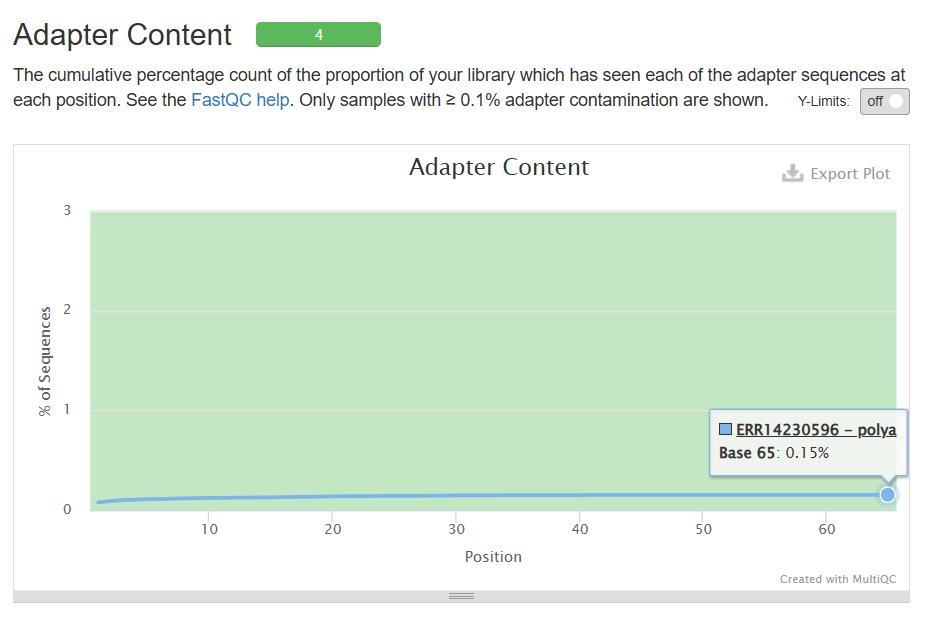

- **Есть ли участки с плохим качеством (Q<20) в конце ридов?**

График Mean Quality Scores показал, что качество выше Q30 по всей длине, значит участков с Q<20 в конце ридов нет.

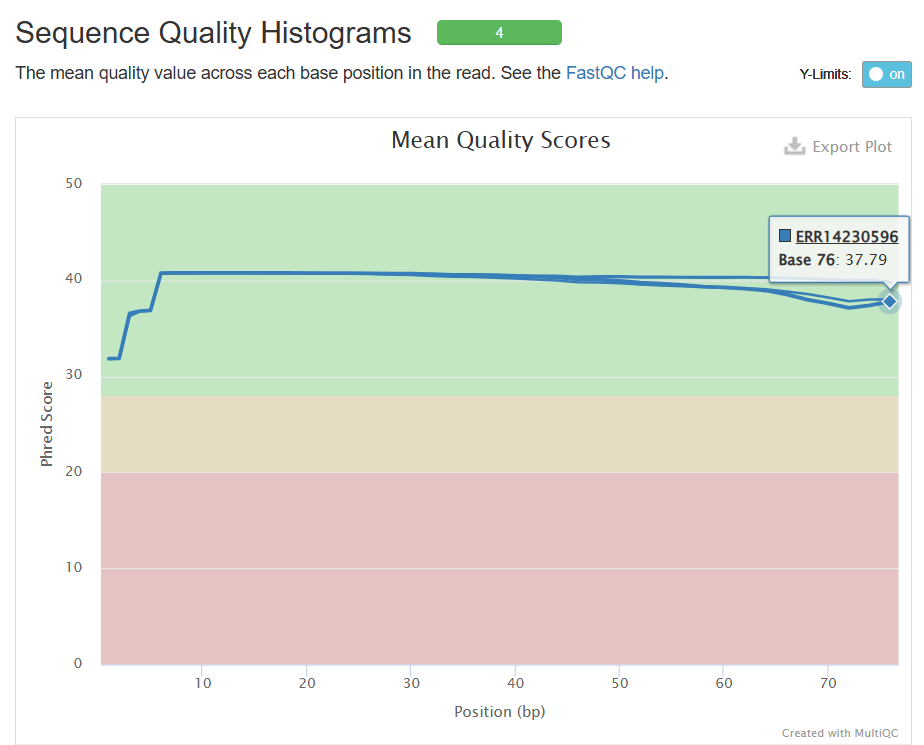

**Результаты получились хорошими, но всё равно проведём тримминг и сопоставим результаты**

Скрипт SLURM для тримминга с параметрами fastp



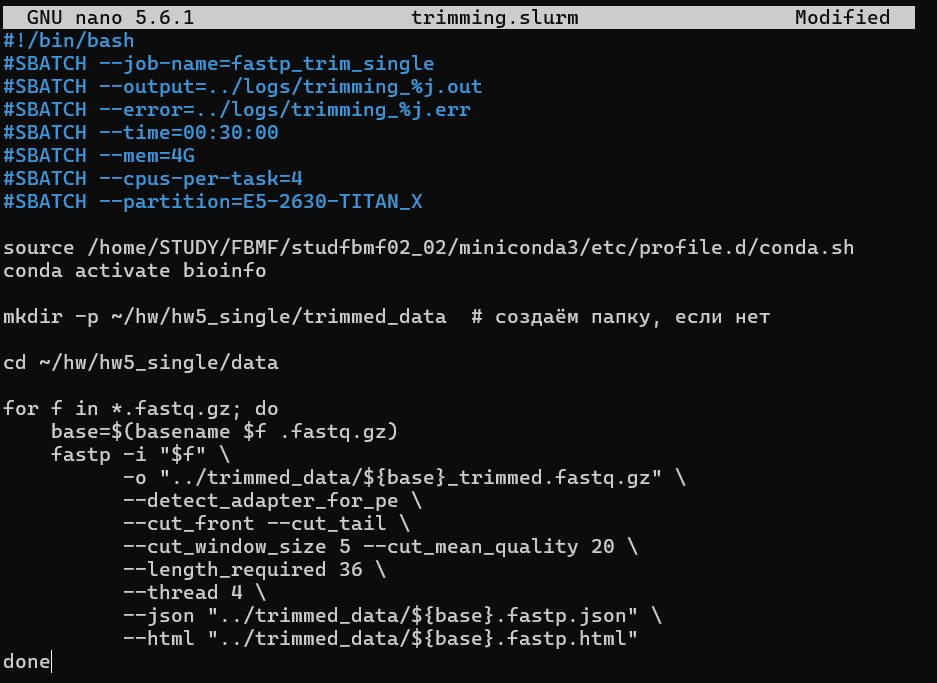

Скриншот папки на сервере c созданными файлами тримминга


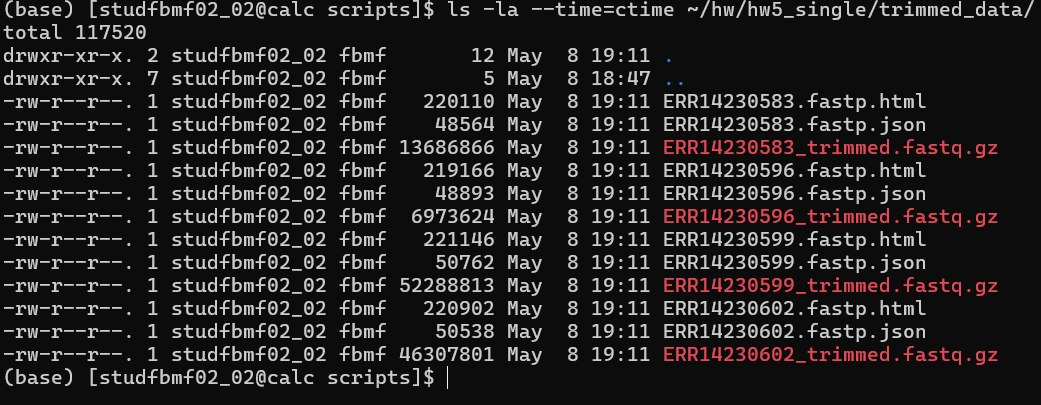

## **Часть 3 — Контроль качества после тримминга**


Запустили FastQC повторно на *_trimmed.fastq.gz и снова собрали отчет MultiQC с помощью скриптов.

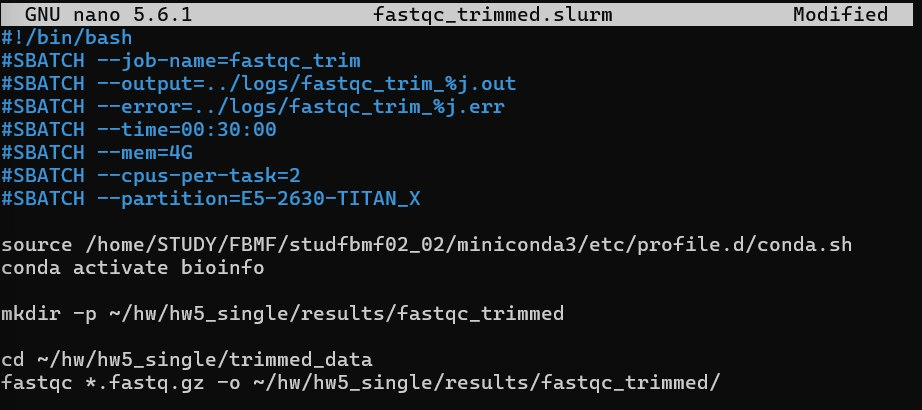

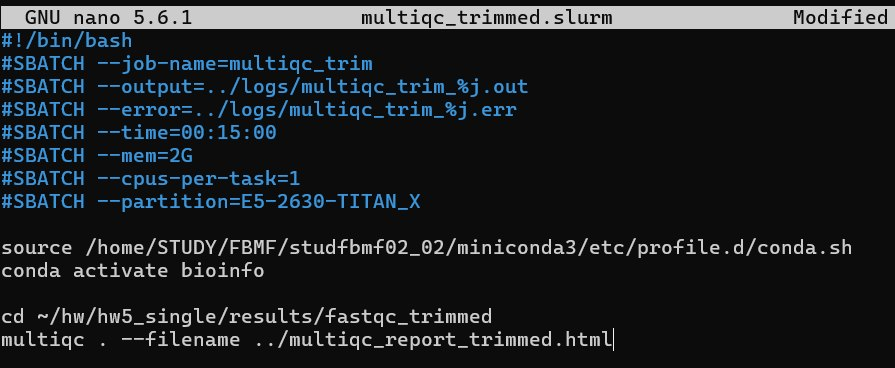

Посмотрим на отчёт  MultiQC и сравним его с данными до тримминга

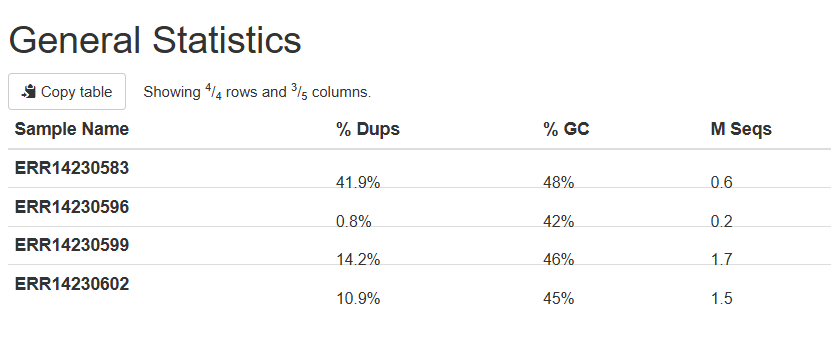

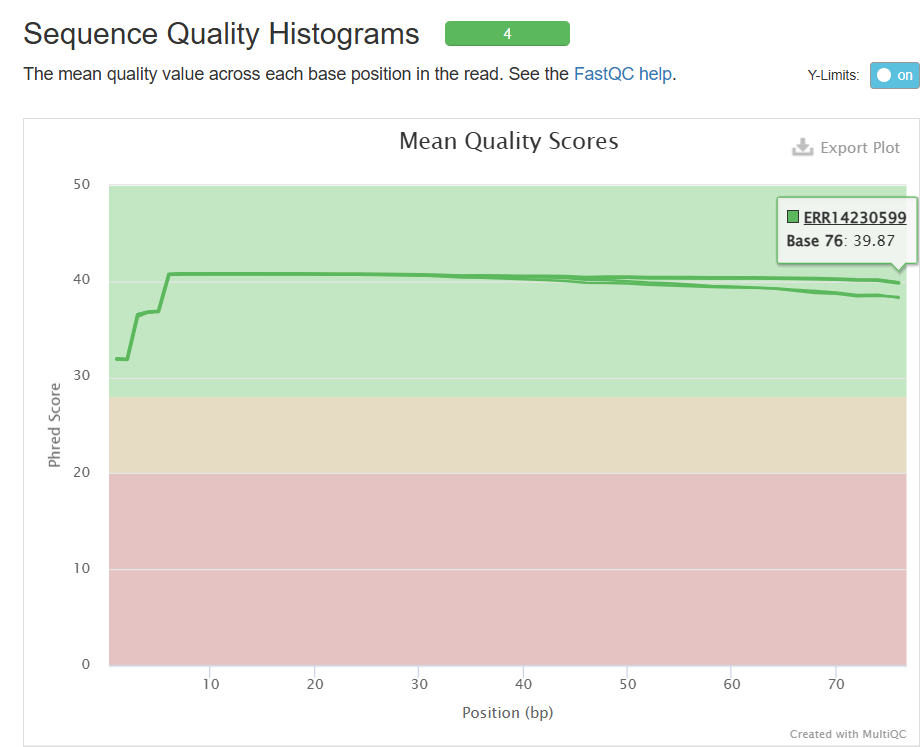

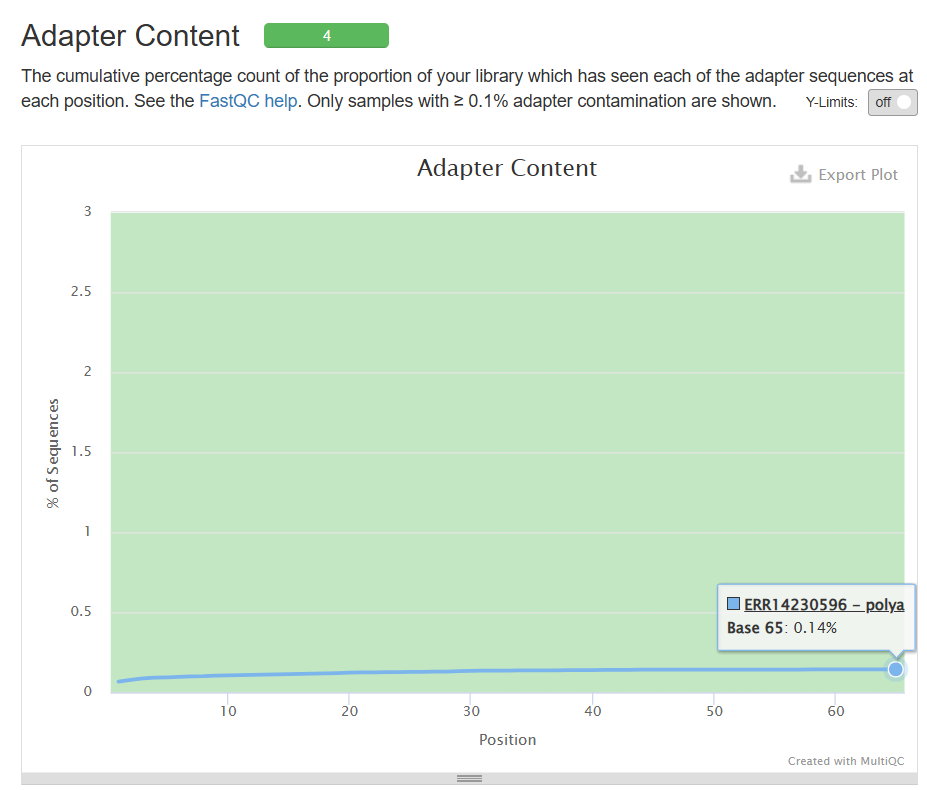

**Сравнение метрик**

| Sample      | Δ Dupes (п.п.) | Δ M Seqs (млн) |
|-------------|----------------|----------------|
| ERR14230583 | **-7.0%**       | -0.2           |
| ERR14230596 | +0.3%           | -0.1           |
| ERR14230599 | **-4.6%**       | -0.3           |
| ERR14230602 | **-4.4%**       | -0.3           |


- **Снижение дупликации** на 4–7% у трёх образцов. Это результат работы параметра `detect_adapter_for_pe` (автоопределение и удаление адаптеров) – адаптерные димеры и короткие ПЦР-дупликаты были отфильтрованы.  
- **Небольшое уменьшение количества ридов** (на 0,1–0,3 млн) — ожидаемо, так как часть ридов отброшена из-за длины <36 п.н. или обрезки концов.  
- **GC% практически не изменился** (±1%) – хороший признак, что тримминг не внёс систематического смещения.

- Образец **ERR14230596** показал незначительный рост дупликации (0,5→0,8%) – это может быть связано с очень малым исходным числом ридов (0,3M) и статистическим шумом; разница в 0,3% не критична.




## **Выводы**

После тримминга (fastp) получены следующие результаты:

- **Качество чтений (Mean Quality Scores)** осталось на высоком уровне: Phred Score >30 по всей длине ридов (как и в сырых данных). Это подтверждает, что изначально качество секвенирования было отличным, и тримминг не ухудшил его.
- **Адаптерная контаминация (Adapter Content)** практически не изменилась: у образца ERR14230596 уровень составил 0,14% (было 0,15%), у остальных образцов – ниже порога отображения (<0,1%). Тримминг не дал значимого снижения из‑за изначально очень низкого уровня адаптеров.
- **Дупликация (% Dupes)**  снизилась на 4–7% у трёх образцов, что, вероятно, связано с обрезкой концов и фильтрацией коротких ридов, удалившей часть дублированных последовательностей.
- **Количество ридов (M Seqs)** уменьшилось на 0,1–0,3 млн – ожидаемая потеря из‑за отбрасывания коротких (<36 п.н.) и обработанных чтений.


Тримминг выполнил поставленную задачу: снизил дупликацию и отфильтровал короткие риды. Качество данных осталось высоким, адаптерная контаминация была незначительной и не потребовала агрессивной обрезки.